# OBRADA PODATAKA


In [1]:
import os
import numpy as np
import gdown
import zipfile
import scipy.fftpack
from sklearn.model_selection import train_test_split
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_curve,auc,precision_recall_curve,average_precision_score

In [2]:
DATASET_PATH = "dataset"

if not os.path.exists(DATASET_PATH):
    print("Skidanje dataseta...")

    gdown.download(
        "https://drive.google.com/uc?id=1k-b9EkXcOALbQFrMmHG-arjAa_KrL15v",
        "dataset.zip",
        quiet=False
    )

    print("Raspakivanje...")
    with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
        zip_ref.extractall(DATASET_PATH)

    os.remove("dataset.zip")
    print("Gotovo!")
else:
    print("Dataset već postoji lokalno.")

dataset_path = os.path.join(DATASET_PATH,"dataset_wake_word_detection")
wake_word = "stop"

wake_word_folder= os.path.join(dataset_path,wake_word)
files= os.listdir(wake_word_folder)

Dataset već postoji lokalno.


In [3]:
audio_file= os.path.join(wake_word_folder,files[0])

In [4]:
signal, sr= librosa.load(audio_file,sr=16000)
print("Sample rate:", sr)
print("Signal shape:", signal.shape)

Sample rate: 16000
Signal shape: (14118,)


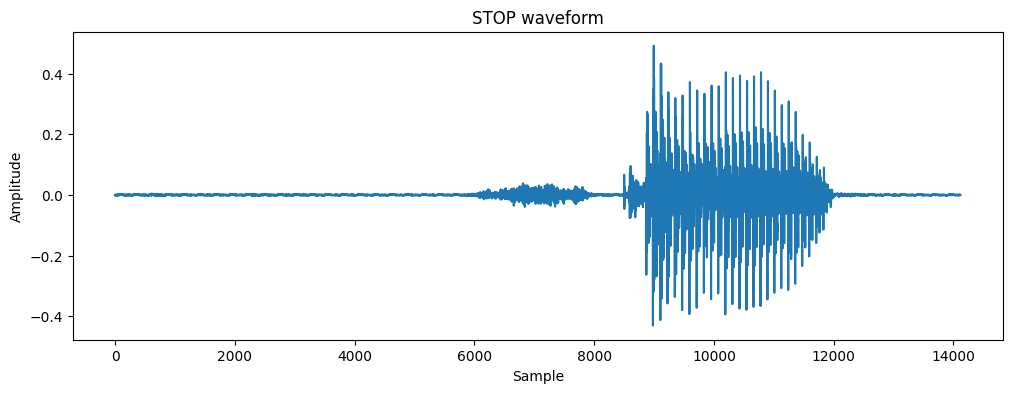

In [5]:
plt.figure(figsize=(12,4))
plt.plot(signal)
plt.title("STOP waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

In [6]:
Audio(signal, rate=sr)

In [7]:
class WakeWordCNNUnified(nn.Module):

    def __init__(self):
        super().__init__()

        self.features= nn.Sequential(

            nn.Conv2d(in_channels=1,out_channels=16,kernel_size=3,padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier= nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x= self.features(x)
        x= self.classifier(x)

        return x

In [8]:
def extract_audio_files_mfcc(dataset_path,wake_word_folder):
    X= []
    y= []

    for file_name in os.listdir(wake_word_folder):
        if file_name.endswith(".wav"):
            file_path= os.path.join(wake_word_folder,file_name)
    
            mfcc= extract_mfcc(file_path)
    
            X.append(mfcc)
            y.append(1)

    for folder_name in os.listdir(dataset_path):
        folder_path= os.path.join(dataset_path,folder_name)
    
        if not os.path.isdir(folder_path):
            continue
    
        if folder_name == wake_word:
            continue
    
        for file_name in os.listdir(folder_path):
            if file_name.endswith(".wav"):
                file_path= os.path.join(folder_path,file_name)
    
                mfcc = extract_mfcc(file_path)
    
                X.append(mfcc)
                y.append(0)
    

    return X,y

In [9]:
def extract_audio_files_lfcc(dataset_path,wake_word_folder):
    X= []
    y= []

    for file_name in os.listdir(wake_word_folder):
        if file_name.endswith(".wav"):
            file_path= os.path.join(wake_word_folder,file_name)
    
            lfcc= extract_lfcc(file_path)
    
            X.append(lfcc)
            y.append(1)

    for folder_name in os.listdir(dataset_path):
        folder_path= os.path.join(dataset_path,folder_name)
    
        if not os.path.isdir(folder_path):
            continue
    
        if folder_name == wake_word:
            continue
    
        for file_name in os.listdir(folder_path):
            if file_name.endswith(".wav"):
                file_path= os.path.join(folder_path,file_name)
    
                lfcc = extract_lfcc(file_path)
    
                X.append(lfcc)
                y.append(0)
    

    return X,y

# MFCC

In [10]:
def extract_mfcc(file_path, n_mfcc=13, max_len=32):
    signal, sr= librosa.load(file_path,sr=16000)

    mfcc= librosa.feature.mfcc(y=signal,sr=sr,n_mfcc=n_mfcc)
    
    if mfcc.shape[1] < max_len:
        pad_width= max_len - mfcc.shape[1]

        mfcc= np.pad(mfcc,pad_width=((0,0),(0,pad_width)),mode='constant')
    else:
        mfcc= mfcc[:, :max_len]

    return mfcc

## Primer MFCC reprezentacije

In [11]:
mfcc= librosa.feature.mfcc(y=signal,sr=sr,n_mfcc=13)
print(mfcc.shape)

(13, 28)


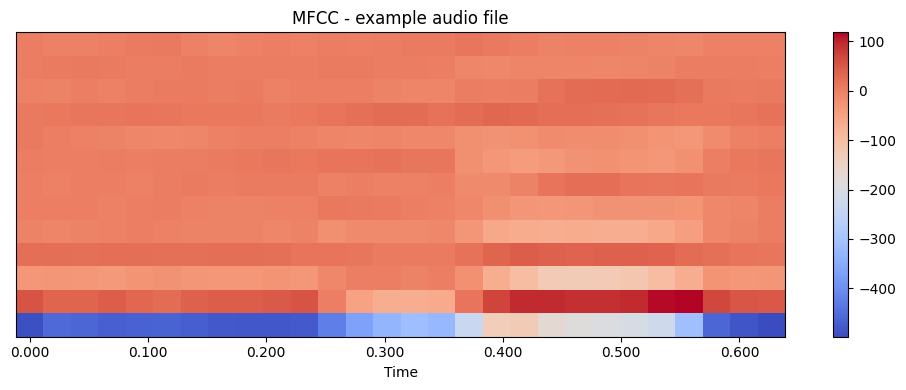

In [12]:
plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc,x_axis='time')

plt.colorbar()
plt.title("MFCC - example audio file")
plt.tight_layout()
plt.show()

In [13]:
X_mfcc= []
y_mfcc= []

In [14]:
X_mfcc,y_mfcc = extract_audio_files_mfcc(dataset_path,wake_word_folder)

In [15]:
X_mfcc = np.array(X_mfcc)
y_mfcc = np.array(y_mfcc)

print("X shape:", X_mfcc.shape)
print("y shape:", y_mfcc.shape)

X shape: (64727, 13, 32)
y shape: (64727,)


In [16]:
X_mfcc_train, X_mfcc_test, y_mfcc_train, y_mfcc_test = train_test_split(X_mfcc,y_mfcc,test_size=0.25,random_state=42,stratify=y_mfcc)

print("X_train:", X_mfcc_train.shape)
print("X_test:", X_mfcc_test.shape)
print("y_train:", y_mfcc_train.shape)
print("y_test:", y_mfcc_test.shape)

X_train: (48545, 13, 32)
X_test: (16182, 13, 32)
y_train: (48545,)
y_test: (16182,)


In [17]:
X_mfcc_train_tensor= torch.tensor(X_mfcc_train, dtype=torch.float32).unsqueeze(1)
X_mfcc_test_tensor= torch.tensor(X_mfcc_test,  dtype=torch.float32).unsqueeze(1)
y_mfcc_train_tensor= torch.tensor(y_mfcc_train, dtype=torch.float32)
y_mfcc_test_tensor= torch.tensor(y_mfcc_test,  dtype=torch.float32)

train_mfcc_dataset= TensorDataset(X_mfcc_train_tensor, y_mfcc_train_tensor)
test_mfcc_dataset= TensorDataset(X_mfcc_test_tensor,  y_mfcc_test_tensor)

train_mfcc_loader= DataLoader(train_mfcc_dataset, batch_size=32, shuffle=True)
test_mfcc_loader= DataLoader(test_mfcc_dataset,  batch_size=32, shuffle=False)

In [18]:
num_negative= (y_mfcc_train == 0).sum()
num_positive= (y_mfcc_train == 1).sum()
pos_weight= torch.tensor([num_negative / num_positive], dtype=torch.float32)

mfcc_model= WakeWordCNNUnified()
mfcc_criterion= nn.BCEWithLogitsLoss(pos_weight=pos_weight)
mfcc_optimizer= optim.Adam(mfcc_model.parameters(), lr=0.001)

In [19]:
num_epochs= 20
train_losses= []
for epoch in range(num_epochs):
    mfcc_model.train()
    running_loss= 0.0
    for inputs, labels in train_mfcc_loader:
        labels= labels.unsqueeze(1)
        mfcc_optimizer.zero_grad()
        outputs= mfcc_model(inputs)
        loss= mfcc_criterion(outputs, labels)
        loss.backward()
        mfcc_optimizer.step()
        running_loss += loss.item() 
    epoch_loss= running_loss / len(train_mfcc_loader)
    train_losses.append(epoch_loss)
    print(f"MFCC Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}")

MFCC Epoch [1/20] Loss: 0.4791
MFCC Epoch [2/20] Loss: 0.2708
MFCC Epoch [3/20] Loss: 0.2175
MFCC Epoch [4/20] Loss: 0.1941
MFCC Epoch [5/20] Loss: 0.1570
MFCC Epoch [6/20] Loss: 0.1478
MFCC Epoch [7/20] Loss: 0.1368
MFCC Epoch [8/20] Loss: 0.1214
MFCC Epoch [9/20] Loss: 0.1269
MFCC Epoch [10/20] Loss: 0.1026
MFCC Epoch [11/20] Loss: 0.1000
MFCC Epoch [12/20] Loss: 0.0934
MFCC Epoch [13/20] Loss: 0.0895
MFCC Epoch [14/20] Loss: 0.0847
MFCC Epoch [15/20] Loss: 0.0845
MFCC Epoch [16/20] Loss: 0.0778
MFCC Epoch [17/20] Loss: 0.0766
MFCC Epoch [18/20] Loss: 0.2725
MFCC Epoch [19/20] Loss: 0.0974
MFCC Epoch [20/20] Loss: 0.0553


In [20]:
mfcc_model.eval()
all_probs,all_preds, all_labels= [], [], []

threshold= 0.96

with torch.no_grad():
    for inputs, labels in test_mfcc_loader:
        outputs= torch.sigmoid(mfcc_model(inputs))
        preds= (outputs >= threshold).float()
        all_probs.extend(outputs.squeeze().numpy())
        all_preds.extend(preds.squeeze().numpy())
        all_labels.extend(labels.numpy())

mfcc_accuracy= accuracy_score(all_labels, all_preds)
print("MFCC Accuracy:", mfcc_accuracy)
print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, zero_division=0))

MFCC Accuracy: 0.9945000617970584
[[15565    22]
 [   67   528]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     15587
         1.0       0.96      0.89      0.92       595

    accuracy                           0.99     16182
   macro avg       0.98      0.94      0.96     16182
weighted avg       0.99      0.99      0.99     16182



In [21]:
mfcc_probs = np.array(all_probs)

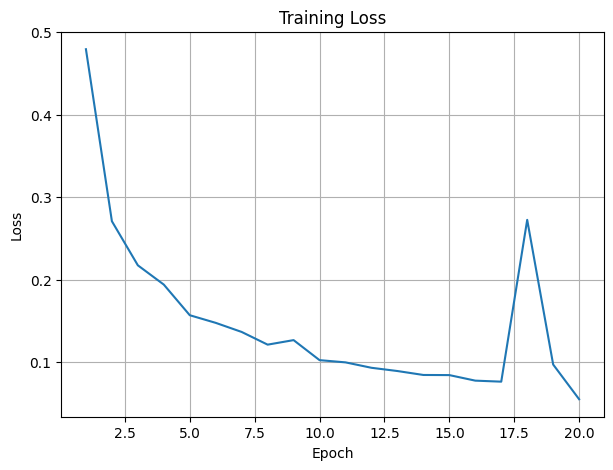

In [22]:
plt.figure(figsize=(7,5))
plt.plot(range(1, num_epochs + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

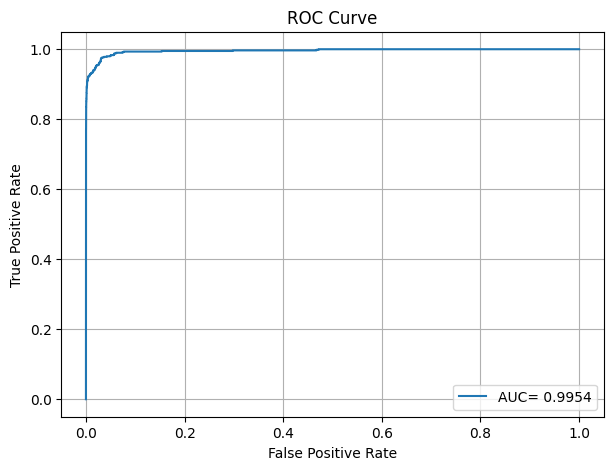

In [23]:
fpr, tpr, roc_thresholds= roc_curve(all_labels, all_probs)
roc_auc= auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC= {roc_auc:.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

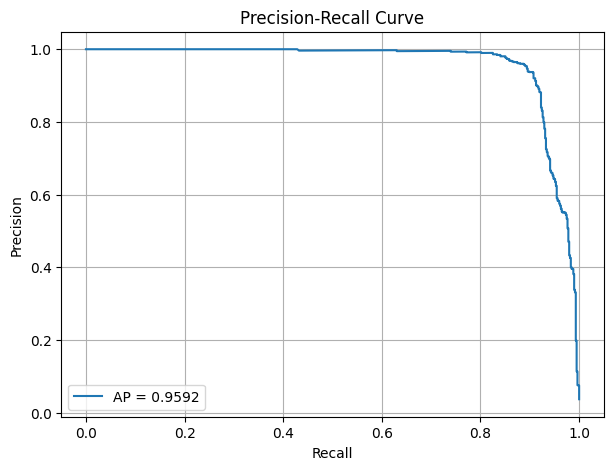

In [24]:
precision, recall, pr_thresholds= precision_recall_curve(all_labels,all_probs)
ap_score= average_precision_score(all_labels, all_probs)

plt.figure(figsize=(7,5))
plt.plot(recall, precision,label=f"AP = {ap_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

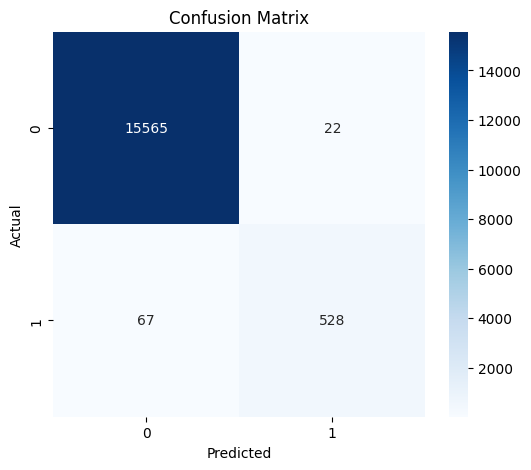

In [25]:
cm= confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# LFCC

### Funkcija koja pretvara zvučni signal u LFCC matricu

In [26]:
def extract_lfcc(
    file_path,
    n_lfcc=13,
    n_fft=512,
    hop_length=256,
    max_len=32
):

    signal, sr = librosa.load(
        file_path,
        sr=16000
    )

    stft = np.abs(
        librosa.stft(
            signal,
            n_fft=n_fft,
            hop_length=hop_length
        )
    )

    spectrogram = stft ** 2

    n_filters = 40

    freqs = np.linspace(
        0,
        sr // 2,
        n_filters + 2
    )

    fft_freqs = librosa.fft_frequencies(
        sr=sr,
        n_fft=n_fft
    )

    filter_bank = np.zeros(
        (n_filters, len(fft_freqs))
    )

    for i in range(1, n_filters + 1):

        left = freqs[i - 1]
        center = freqs[i]
        right = freqs[i + 1]

        for j, freq in enumerate(fft_freqs):

            if left <= freq <= center:

                filter_bank[i - 1, j] = (
                    (freq - left)
                    / (center - left)
                )

            elif center <= freq <= right:

                filter_bank[i - 1, j] = (
                    (right - freq)
                    / (right - center)
                )

    filtered_spectrum = np.dot(
        filter_bank,
        spectrogram
    )

    log_spectrum = np.log(
        filtered_spectrum + 1e-10
    )

    lfcc = scipy.fftpack.dct(
        log_spectrum,
        axis=0,
        norm='ortho'
    )

    lfcc = lfcc[:n_lfcc]

    if lfcc.shape[1] < max_len:

        pad_width = max_len - lfcc.shape[1]

        lfcc = np.pad(
            lfcc,
            pad_width=((0,0),(0,pad_width)),
            mode='constant'
        )

    else:

        lfcc = lfcc[:, :max_len]

    return lfcc

### Prikaz jedne LFCC matrice za reč STOP

In [27]:
audio_file = os.path.join(
    wake_word_folder,
    os.listdir(
        os.path.join(dataset_path, "stop")
    )[0]
)

lfcc = extract_lfcc(audio_file)

print(lfcc.shape)

(13, 32)


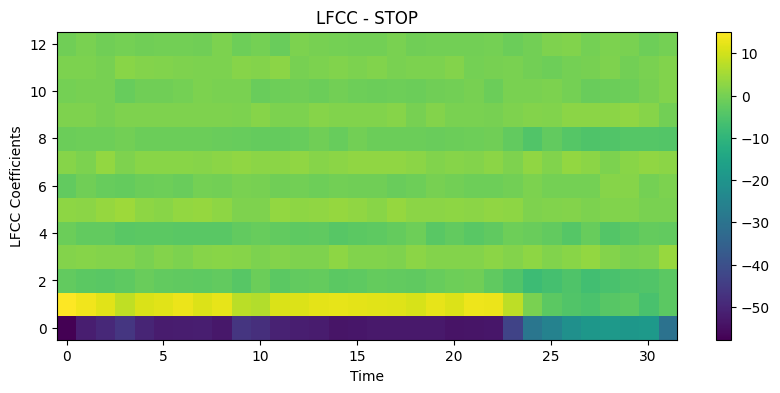

In [28]:
plt.figure(figsize=(10,4))

plt.imshow(
    lfcc,
    aspect='auto',
    origin='lower'
)

plt.colorbar()
plt.title("LFCC - STOP")
plt.xlabel("Time")
plt.ylabel("LFCC Coefficients")
plt.show()

#### LFCC matrica prikazuje karakteristične promene frekvencijskih komponenti reči „STOP“ kroz vreme, pri čemu su najizraženije niže frekvencije tipične za govorni signal. Razlike u intenzitetu boja predstavljaju promene energije tokom izgovora reči, što omogućava modelu da prepozna njen jedinstveni obrazac.

### Učitavanje podataka i dodeljivanje klasa

In [29]:
X_lfcc = []
y_lfcc = []

In [30]:
X_lfcc,y_lfcc = extract_audio_files_lfcc(dataset_path,wake_word_folder)

In [31]:
X_lfcc = np.array(X_lfcc)
y_lfcc = np.array(y_lfcc)

print(X_lfcc.shape)
print(y_lfcc.shape)

(64727, 13, 32)
(64727,)


### Podela na trening i test skup

In [32]:
X_lfcc_train, X_lfcc_test, y_lfcc_train, y_lfcc_test = train_test_split(
    X_lfcc,
    y_lfcc,
    test_size=0.25,
    random_state=42,
    stratify=y_lfcc
)

print("X_lfcc_train:", X_lfcc_train.shape)
print("X_lfcc_test:", X_lfcc_test.shape)
print("y_lfcc_train:", y_lfcc_train.shape)
print("y_lfcc_test:", y_lfcc_test.shape)

X_lfcc_train: (48545, 13, 32)
X_lfcc_test: (16182, 13, 32)
y_lfcc_train: (48545,)
y_lfcc_test: (16182,)


### CNN model

In [33]:
X_lfcc_train_tensor = torch.tensor(
    X_lfcc_train,
    dtype=torch.float32
)

X_lfcc_test_tensor = torch.tensor(
    X_lfcc_test,
    dtype=torch.float32
)

y_lfcc_train_tensor = torch.tensor(
    y_lfcc_train,
    dtype=torch.float32
)

y_lfcc_test_tensor = torch.tensor(
    y_lfcc_test,
    dtype=torch.float32
)

In [34]:
X_lfcc_train_tensor = X_lfcc_train_tensor.unsqueeze(1)
X_lfcc_test_tensor = X_lfcc_test_tensor.unsqueeze(1)

print(X_lfcc_train_tensor.shape)
print(X_lfcc_test_tensor.shape)

torch.Size([48545, 1, 13, 32])
torch.Size([16182, 1, 13, 32])


In [35]:
lfcc_train_dataset = TensorDataset(
    X_lfcc_train_tensor,
    y_lfcc_train_tensor
)

lfcc_test_dataset = TensorDataset(
    X_lfcc_test_tensor,
    y_lfcc_test_tensor
)

lfcc_train_loader = DataLoader(
    lfcc_train_dataset,
    batch_size=32,
    shuffle=True
)

lfcc_test_loader = DataLoader(
    lfcc_test_dataset,
    batch_size=32,
    shuffle=False
)

In [36]:
lfcc_model = WakeWordCNNUnified()

print(lfcc_model)

WakeWordCNNUnified(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropou

In [37]:
num_negative= (y_lfcc_train == 0).sum()
num_positive= (y_lfcc_train == 1).sum()
pos_weight= torch.tensor([num_negative / num_positive], dtype=torch.float32)

lfcc_criterion= nn.BCEWithLogitsLoss(pos_weight=pos_weight)
lfcc_optimizer= optim.Adam(lfcc_model.parameters(), lr=0.001)

In [38]:
num_epochs= 20
train_losses= []
for epoch in range(num_epochs):
    lfcc_model.train()
    running_loss= 0.0
    for inputs, labels in lfcc_train_loader:
        labels= labels.unsqueeze(1)
        lfcc_optimizer.zero_grad()
        outputs= lfcc_model(inputs)
        loss= lfcc_criterion(outputs, labels)
        loss.backward()
        lfcc_optimizer.step()
        running_loss += loss.item() 
    epoch_loss= running_loss / len(lfcc_train_loader)
    train_losses.append(epoch_loss)
    print(f"MFCC Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f}")

MFCC Epoch [1/20] Loss: 0.8181
MFCC Epoch [2/20] Loss: 0.5865
MFCC Epoch [3/20] Loss: 0.5102
MFCC Epoch [4/20] Loss: 0.4909
MFCC Epoch [5/20] Loss: 0.4617
MFCC Epoch [6/20] Loss: 0.4366
MFCC Epoch [7/20] Loss: 0.4211
MFCC Epoch [8/20] Loss: 0.4072
MFCC Epoch [9/20] Loss: 0.3955
MFCC Epoch [10/20] Loss: 0.3789
MFCC Epoch [11/20] Loss: 0.3747
MFCC Epoch [12/20] Loss: 0.3629
MFCC Epoch [13/20] Loss: 0.3648
MFCC Epoch [14/20] Loss: 0.3455
MFCC Epoch [15/20] Loss: 0.3288
MFCC Epoch [16/20] Loss: 0.3318
MFCC Epoch [17/20] Loss: 0.3228
MFCC Epoch [18/20] Loss: 0.3117
MFCC Epoch [19/20] Loss: 0.4420
MFCC Epoch [20/20] Loss: 0.3170


### Evaluacija modela na test skupu

In [39]:
lfcc_model.eval()
all_probs,all_preds, all_labels= [], [], []

threshold= 0.96

with torch.no_grad():
    for inputs, labels in lfcc_test_loader:
        outputs= torch.sigmoid(lfcc_model(inputs))
        preds= (outputs >= threshold).float()
        all_probs.extend(outputs.squeeze().numpy())
        all_preds.extend(preds.squeeze().numpy())
        all_labels.extend(labels.numpy())

lfcc_accuracy= accuracy_score(all_labels, all_preds)
print("LFCC Accuracy:", lfcc_accuracy)
print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, zero_division=0))

LFCC Accuracy: 0.9841181559757756
[[15534    53]
 [  204   391]]
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     15587
         1.0       0.88      0.66      0.75       595

    accuracy                           0.98     16182
   macro avg       0.93      0.83      0.87     16182
weighted avg       0.98      0.98      0.98     16182



In [40]:
lfcc_probs = np.array(all_probs)

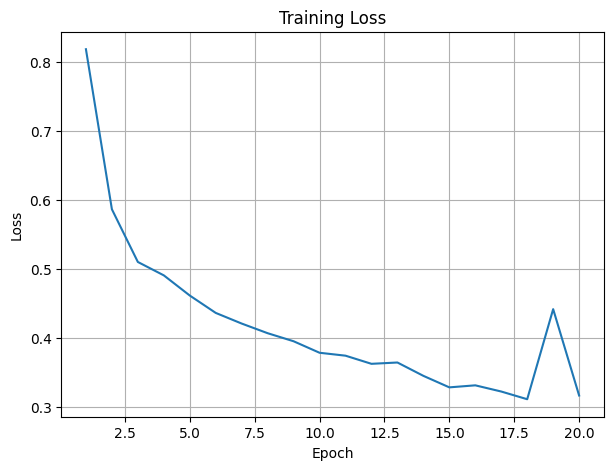

In [41]:
plt.figure(figsize=(7,5))
plt.plot(range(1, num_epochs + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

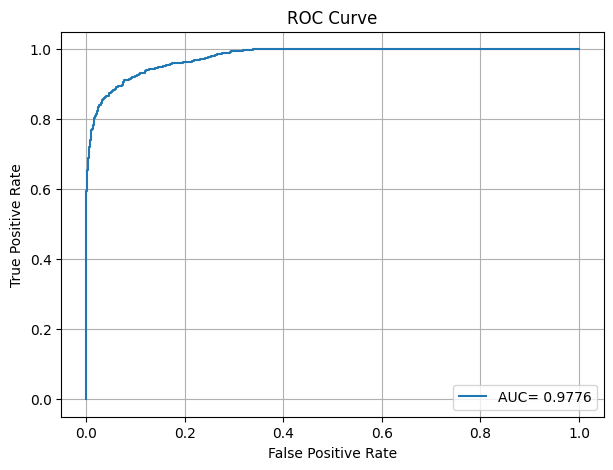

In [42]:
fpr, tpr, roc_thresholds= roc_curve(all_labels, all_probs)
roc_auc= auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC= {roc_auc:.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

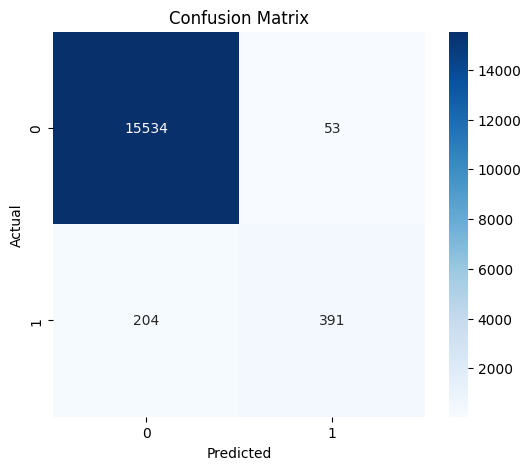

In [43]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

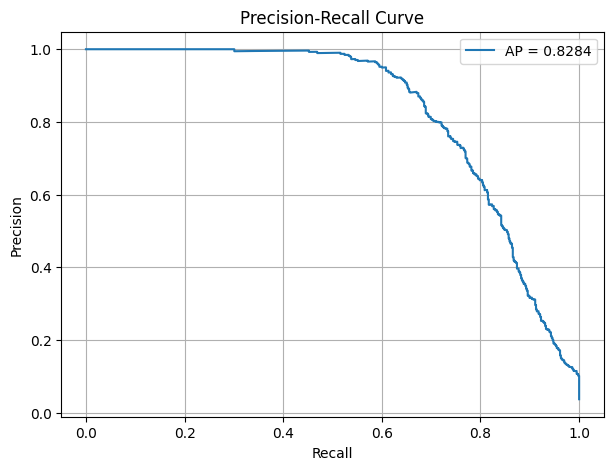

In [44]:
precision, recall, pr_thresholds= precision_recall_curve(all_labels,all_probs)
ap_score= average_precision_score(all_labels, all_probs)

plt.figure(figsize=(7,5))
plt.plot(recall, precision,label=f"AP = {ap_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

# POREDJENJE MFCC I LFCC

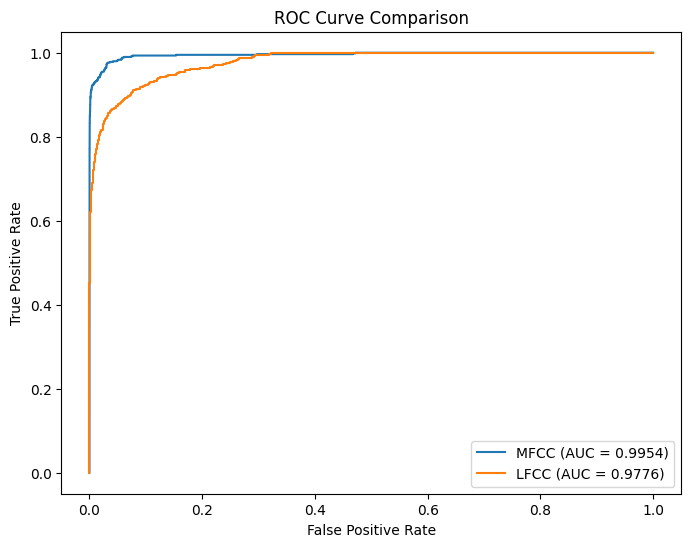

In [45]:
fpr_mfcc, tpr_mfcc, _ = roc_curve(y_mfcc_test, mfcc_probs)
roc_auc_mfcc = auc(fpr_mfcc, tpr_mfcc)

fpr_lfcc, tpr_lfcc, _ = roc_curve(y_lfcc_test, lfcc_probs)
roc_auc_lfcc = auc(fpr_lfcc, tpr_lfcc)

plt.figure(figsize=(8,6))
plt.plot(fpr_mfcc,tpr_mfcc,label=f"MFCC (AUC = {roc_auc_mfcc:.4f})")

plt.plot(fpr_lfcc,tpr_lfcc,label=f"LFCC (AUC = {roc_auc_lfcc:.4f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

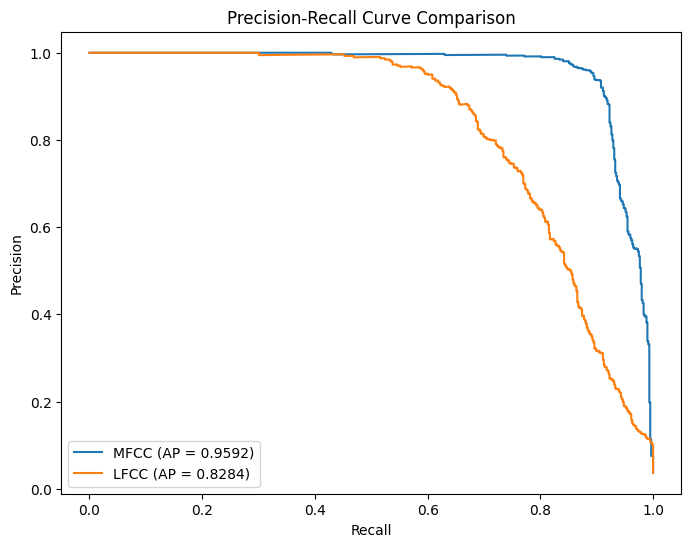

In [46]:
precision_mfcc, recall_mfcc, _ = precision_recall_curve(y_mfcc_test,mfcc_probs)
ap_mfcc = average_precision_score(y_mfcc_test, mfcc_probs)

precision_lfcc, recall_lfcc, _ = precision_recall_curve(y_lfcc_test,lfcc_probs)
ap_lfcc = average_precision_score(y_lfcc_test, lfcc_probs)

plt.figure(figsize=(8,6))

plt.plot(recall_mfcc,precision_mfcc,label=f"MFCC (AP = {ap_mfcc:.4f})")

plt.plot(recall_lfcc,precision_lfcc,label=f"LFCC (AP = {ap_lfcc:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()

plt.show()